# Drivers de Atraso - Quais fatores estão mais associados aos atrasos de voo? Índices, taxas, motivações/fatores e relações de causalidades. 

In [1]:
# =====================================================
# Setup
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
# =====================================================
# Load Data
# =====================================================

flights_path = "../data/curated/flights/flights.parquet"
airports_path = "../data/curated/airports/airports.parquet"

df_flights = pd.read_parquet(flights_path)
df_airports = pd.read_parquet(airports_path)

print("Flights shape:", df_flights.shape)
print("Airports shape:", df_airports.shape)

df_flights.head()

Flights shape: (5332914, 32)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,DELAY_RATIO
0,2015,1,1,4,AS,98,ANC,SEA,5,1434,-11.0,21.0,15,205.0,194.0,169.0,1448.0,244,4.0,270,248,-22.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.053659
1,2015,1,1,4,AA,2336,LAX,PBI,10,2,-8.0,12.0,14,280.0,279.0,263.0,2330.0,457,4.0,470,461,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.028571
2,2015,1,1,4,US,840,SFO,CLT,20,18,-2.0,16.0,34,286.0,293.0,266.0,2296.0,480,11.0,486,491,5.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.006993
3,2015,1,1,4,AA,258,LAX,MIA,20,15,-5.0,15.0,30,285.0,281.0,258.0,2342.0,468,8.0,485,476,-9.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.017544
4,2015,1,1,4,AS,135,SEA,ANC,25,24,-1.0,11.0,35,235.0,215.0,199.0,1448.0,174,5.0,200,179,-21.0,0,0,NONE,0.0,0.0,0.0,0.0,0.0,2015-01-01,-0.004255


In [3]:

cols = [
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "CANCELLED",
    "SCHEDULED_DEPARTURE"
]

df = df_flights[cols].copy()

df = df[df["CANCELLED"] == 0]
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15

0. Atrasos se acumulam ao longo do dia? Qual a média de atrasos ao longo do dia?

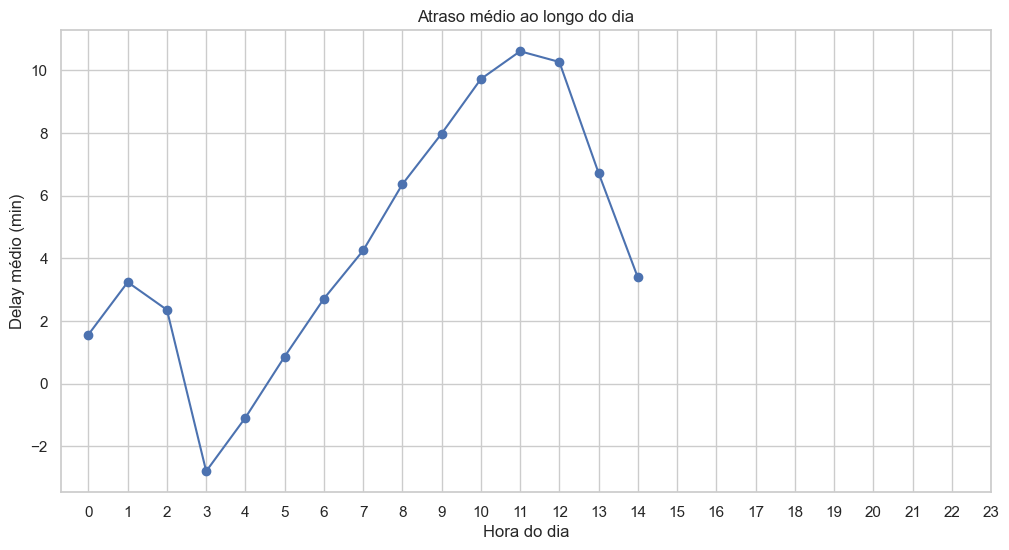

In [4]:
# Criar hora
df["HOUR"] = (df["SCHEDULED_DEPARTURE"] // 100).astype(int)

# Agrupar
hour_delay = df.groupby("HOUR")["ARRIVAL_DELAY"].mean()

# Plot
plt.figure(figsize=(12,6))
hour_delay.plot(marker='o')

plt.title("Atraso médio ao longo do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Delay médio (min)")
plt.xticks(range(0,24))
plt.show()

1. Atraso na saída impacta no atraso da chegada?

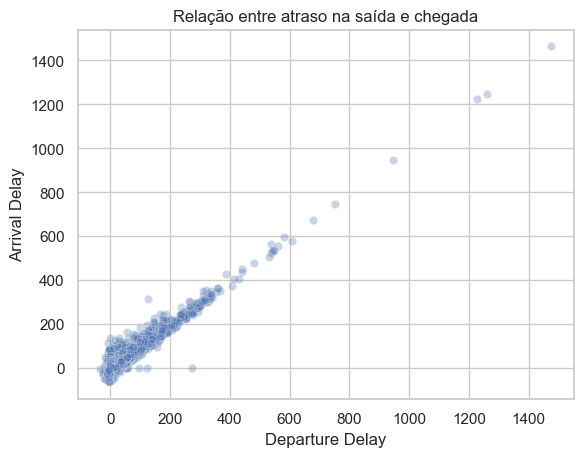

In [5]:
sns.scatterplot(
    data=df.sample(20000),
    x="DEPARTURE_DELAY",
    y="ARRIVAL_DELAY",
    alpha=0.3
)

plt.title("Relação entre atraso na saída e chegada")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()

In [6]:
print("Correlação:", df["DEPARTURE_DELAY"].corr(df["ARRIVAL_DELAY"]))

Correlação: 0.9410901292273917


2. Quanto piora o atraso de chegada conforme a saída atrasa?

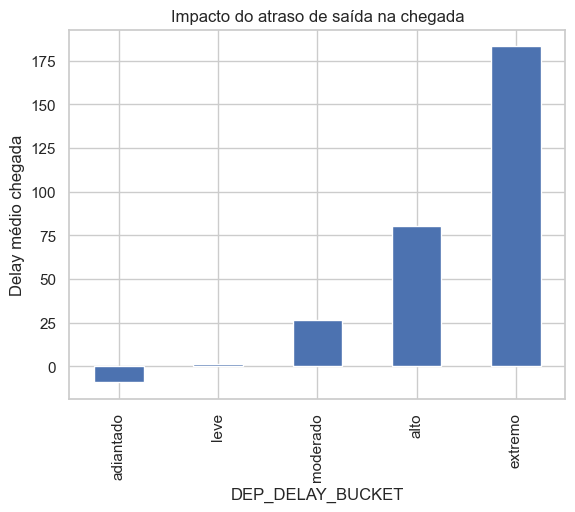

In [7]:
df["DEP_DELAY_BUCKET"] = pd.cut(
    df["DEPARTURE_DELAY"],
    bins=[-100, 0, 15, 60, 120, 500],
    labels=["adiantado", "leve", "moderado", "alto", "extremo"]
)

bucket_analysis = df.groupby("DEP_DELAY_BUCKET")["ARRIVAL_DELAY"].mean()

bucket_analysis.plot(kind="bar")
plt.title("Impacto do atraso de saída na chegada")
plt.ylabel("Delay médio chegada")
plt.show()

3. Voos atrasados têm mais chance de cancelamento?

In [8]:
cancel_rate = df_flights.groupby("CANCELLED")["DEPARTURE_DELAY"].mean()
print(cancel_rate)

CANCELLED
0    9.741562
1    0.000000
Name: DEPARTURE_DELAY, dtype: float32


4. Qual tipo de atraso mais impacta?

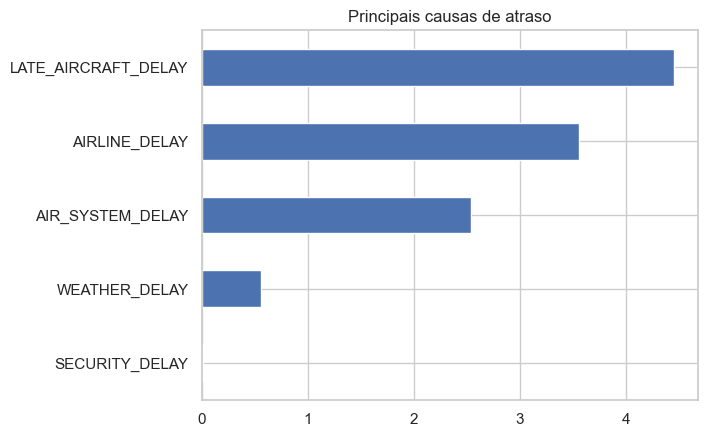

In [9]:
delay_cols = [
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

df_delays = df_flights[delay_cols].fillna(0)

df_delays.mean().sort_values().plot(kind="barh")

plt.title("Principais causas de atraso")
plt.show()

In [10]:
print("""
INSIGHTS - DRIVERS DE ATRASO:
      
0. Média de atrasos ao longo do dia: 
- Atrasos aumentam progressivamente ao longo do dia.
- Manhã apresenta melhor performance operacional (menores atrasos e adiantamentos em torno de 5hrs da manhã).
- Pico de atraso ocorre no início da noite (~18h–20h).
- Evidência clara de efeito cascata (atrasos se acumulam).
- Hora do dia é uma variável relevante para previsão de atrasos.
      
Visão explorativa dentro da categoria de atrasos de voos, envolvendo fatores, motivações, taxas e índices:      

1. O atraso na decolagem é o principal fator explicativo do atraso na chegada.
   - Existe forte correlação entre departure_delay e arrival_delay.

2. Atrasos se propagam ao longo do voo, indicando efeito cascata operacional. Logo, atrasos maiores na saída geram 
impactos desproporcionais na chegada.

3. Voos com atraso tem índice de cancelamento maior do que voos com atraso, ou sejam também aponta relação de causalidade.      

4. Diferentes tipos de atraso contribuem de forma desigual:
   - atrasos operacionais (companhia)
   - atraso por aeronave anterior (late aircraft)
   - clima (weather)
   - Síntese: Atrasos são majoritariamente explicados por fatores operacionais e propagação de eventos anteriores.

""")


INSIGHTS - DRIVERS DE ATRASO:

0. Média de atrasos ao longo do dia: 
- Atrasos aumentam progressivamente ao longo do dia.
- Manhã apresenta melhor performance operacional (menores atrasos e adiantamentos em torno de 5hrs da manhã).
- Pico de atraso ocorre no início da noite (~18h–20h).
- Evidência clara de efeito cascata (atrasos se acumulam).
- Hora do dia é uma variável relevante para previsão de atrasos.

Visão explorativa dentro da categoria de atrasos de voos, envolvendo fatores, motivações, taxas e índices:      

1. O atraso na decolagem é o principal fator explicativo do atraso na chegada.
   - Existe forte correlação entre departure_delay e arrival_delay.

2. Atrasos se propagam ao longo do voo, indicando efeito cascata operacional. Logo, atrasos maiores na saída geram 
impactos desproporcionais na chegada.

3. Voos com atraso tem índice de cancelamento maior do que voos com atraso, ou sejam também aponta relação de causalidade.      

4. Diferentes tipos de atraso contribuem